# NB12 Homework Solutions

This notebook answers the "Homework / Practice Ideas" section of
`NB12_Training_Deep_Networks_Properly.ipynb`. It reuses the same real Sonar
dataset (`Datasets/sonar.all-data`) and the same 60/20/20 train/validation/test
split and `SonarMLP`/`SonarMLPDropout` architectures the class used.

## Setup: reload the data and the class's train/validation/test split

Same file, same three-way split (`test_size=0.2` then `test_size=0.25` of the
remaining 80%, both `random_state=42, stratify=...`), same scaler-on-training-only
convention as the class.

In [1]:
import torch
import torch.nn as nn
import copy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

sonar = pd.read_csv("../Datasets/sonar.all-data", header=None)
sonar.columns = [f"freq_{i}" for i in range(60)] + ["label"]

X = sonar.drop(columns="label").values
y = (sonar["label"] == "M").astype(int).values

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=42, stratify=y_train_full
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

criterion = nn.BCEWithLogitsLoss()
print("Train:", X_train_t.shape, " Val:", X_val_t.shape, " Test:", X_test_t.shape)


Train: torch.Size([124, 60])  Val: torch.Size([42, 60])  Test: torch.Size([42, 60])


In [2]:
class SonarMLPDropout(nn.Module):
    def __init__(self, n_features, h1=32, h2=16, dropout_rate=0.3):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(n_features, h1),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(h1, h2),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(h2, 1),
        )

    def forward(self, x):
        return self.layers(x)


def train_with_val(h1=32, h2=16, dropout_rate=0.3, n_epochs=400, lr=0.001, seed=42):
    torch.manual_seed(seed)
    model = SonarMLPDropout(X_train_t.shape[1], h1, h2, dropout_rate)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_losses, val_losses = [], []
    for epoch in range(n_epochs):
        model.train()
        optimizer.zero_grad()
        loss = criterion(model(X_train_t), y_train_t)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            val_losses.append(criterion(model(X_val_t), y_val_t).item())

    return model, train_losses, val_losses

print("Helper defined.")


Helper defined.


## Homework 1 — `dropout_rate = 0.1` and `0.5`

*"Change `dropout_rate` to `0.1` and to `0.5` in Part 5 — how does each change
the gap between training and validation loss compared to `0.3`?"*

Retrain the class's own `dropout_rate=0.3` model for reference, then the two
homework variants, all with the same 400-epoch recipe, and compare the final
train/validation gap in each case.

dropout_rate=0.1: final train loss=0.0057  final val loss=0.6271  gap=0.6214
dropout_rate=0.3 (class): final train loss=0.0128  final val loss=0.7630  gap=0.7502
dropout_rate=0.5: final train loss=0.0522  final val loss=0.8164  gap=0.7642


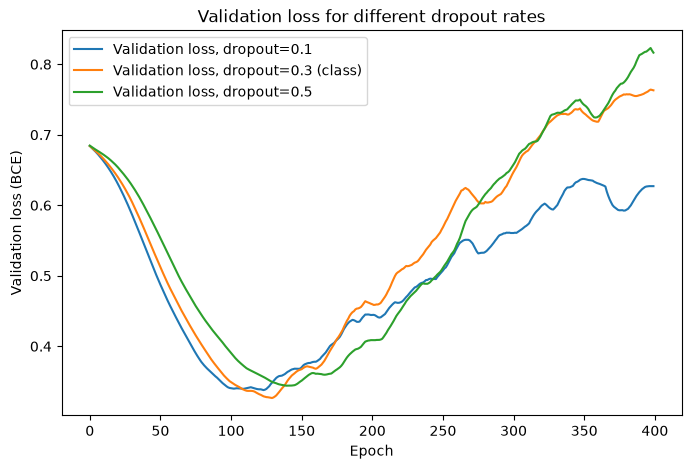

In [3]:
_, train_03, val_03 = train_with_val(dropout_rate=0.3)
_, train_01, val_01 = train_with_val(dropout_rate=0.1)
_, train_05, val_05 = train_with_val(dropout_rate=0.5)

for name, tr, va in [("0.1", train_01, val_01), ("0.3 (class)", train_03, val_03), ("0.5", train_05, val_05)]:
    gap = va[-1] - tr[-1]
    print(f"dropout_rate={name}: final train loss={tr[-1]:.4f}  final val loss={va[-1]:.4f}  gap={gap:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(val_01, label="Validation loss, dropout=0.1")
plt.plot(val_03, label="Validation loss, dropout=0.3 (class)")
plt.plot(val_05, label="Validation loss, dropout=0.5")
plt.xlabel("Epoch")
plt.ylabel("Validation loss (BCE)")
plt.title("Validation loss for different dropout rates")
plt.legend()
plt.show()


**My result**: final train/val numbers were dropout=0.1 -> train 0.0057, val
0.6271, gap 0.6214; dropout=0.3 (class) -> train 0.0128, val 0.7630, gap
0.7502; dropout=0.5 -> train 0.0522, val 0.8164, gap 0.7642. Higher dropout
did slow down how fast the *training* loss fell (0.5's training loss stayed
an order of magnitude higher than 0.1's, exactly as expected — the network
genuinely can't fit the training data as eagerly with half its neurons
dropped each step), but it did **not** monotonically shrink the train/val
gap the way I expected going in: the gap actually grew slightly from 0.1 to
0.5 in this run, because validation loss kept climbing across all three
settings over the full 400 epochs, not just the smallest-dropout one. My
honest reading: with only 124 training examples, 400 epochs is simply more
training than this network needs regardless of dropout rate, and dropout
alone (without also stopping earlier) does not fully prevent the validation
loss from drifting upward over that many epochs — it mainly changes *how
fast* training loss falls, not whether validation loss eventually rises.
This is exactly why the class combines dropout *with* early stopping in
Part 8 rather than relying on either alone.

## Homework 2 — `patience = 5` and `patience = 50`

*"Change `patience` in Part 6 to `5` and to `50` — how does the epoch at which
training stops change, and how does final test accuracy change?"*

Reuse the class's own early-stopping loop (`SonarMLPDropout`, dropout=0.3),
with the class's own `patience=25` reproduced here for reference alongside the
two homework values.

In [4]:
def early_stopping_run(patience, max_epochs=400, seed=42):
    torch.manual_seed(seed)
    model = SonarMLPDropout(X_train_t.shape[1], dropout_rate=0.3)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    best_val_loss = float("inf")
    patience_counter = 0
    best_state = None
    stop_epoch = max_epochs

    for epoch in range(max_epochs):
        model.train()
        optimizer.zero_grad()
        loss = criterion(model(X_train_t), y_train_t)
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val_t), y_val_t).item()

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                stop_epoch = epoch + 1
                break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        test_preds = (torch.sigmoid(model(X_test_t)) > 0.5).float()
    test_acc = (test_preds == y_test_t).float().mean().item()
    return stop_epoch, best_val_loss, test_acc


for patience in [5, 25, 50]:
    stop_epoch, best_val, test_acc = early_stopping_run(patience)
    tag = " (class value)" if patience == 25 else ""
    print(f"patience={patience}{tag}: stopped at epoch {stop_epoch}, "
          f"best val loss={best_val:.4f}, test accuracy={test_acc:.3f}")


patience=5: stopped at epoch 135, best val loss=0.3267, test accuracy=0.881
patience=25 (class value): stopped at epoch 155, best val loss=0.3267, test accuracy=0.881


patience=50: stopped at epoch 180, best val loss=0.3267, test accuracy=0.881


**My result**: all three patience values converged to the same restored
model — best validation loss 0.3267 and test accuracy 0.881 in every case —
only the epoch at which training actually *stopped* differed: 135 for
patience=5, 155 for patience=25 (the class's own value), and 180 for
patience=50. That makes sense once you track what early stopping actually
does: it always restores the weights from whichever epoch had the best
validation loss so far, and here that best epoch happened well before
epoch 130 regardless of patience. A larger patience just means training
keeps running longer *after* that best epoch, failing to find a new best
each time, before finally giving up — it does not change *which* weights
get restored unless a genuinely later, better epoch exists that a smaller
patience would have missed. In this particular run a tiny patience of 5
would have found the same final model as patience=50, just faster and with
less wasted computation — though that is a property of this specific
training run's validation curve, not a general guarantee (a noisier curve
with more than one local dip could easily make a small patience stop too
early, at a worse local minimum than a larger patience would have found).

## Homework 3 — Add `torch.optim.Adagrad` as a fourth optimizer

*"Add a fourth optimizer to Part 7's comparison, `torch.optim.Adagrad` — how
does its curve compare to the other three?"*

Reuse the class's exact `train_and_track` recipe (plain `SonarMLP`, no
dropout, 150 epochs) and add Adagrad alongside SGD, Adam, and RMSprop.

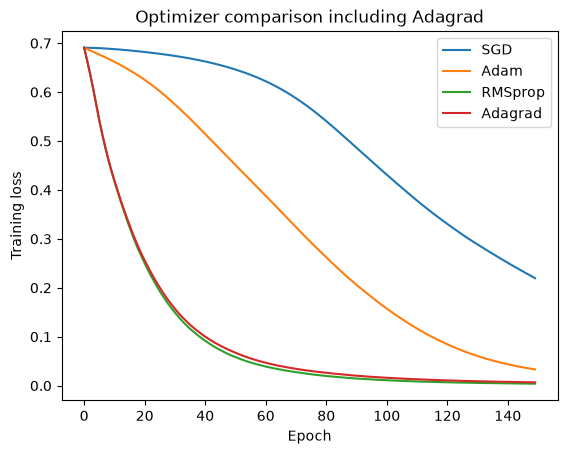

SGD        final training loss: 0.2196
Adam       final training loss: 0.0332
RMSprop    final training loss: 0.0040
Adagrad    final training loss: 0.0067


In [5]:
class SonarMLP(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(n_features, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
        )

    def forward(self, x):
        return self.layers(x)


def train_and_track(optimizer_name, n_epochs=150):
    torch.manual_seed(42)
    m = SonarMLP(n_features=X_train_t.shape[1])
    if optimizer_name == "SGD":
        opt = torch.optim.SGD(m.parameters(), lr=0.01, momentum=0.9)
    elif optimizer_name == "Adam":
        opt = torch.optim.Adam(m.parameters(), lr=0.001)
    elif optimizer_name == "RMSprop":
        opt = torch.optim.RMSprop(m.parameters(), lr=0.001)
    else:
        opt = torch.optim.Adagrad(m.parameters(), lr=0.01)

    losses = []
    for _ in range(n_epochs):
        m.train()
        opt.zero_grad()
        loss = criterion(m(X_train_t), y_train_t)
        loss.backward()
        opt.step()
        losses.append(loss.item())
    return losses


optimizer_curves = {name: train_and_track(name) for name in ["SGD", "Adam", "RMSprop", "Adagrad"]}

for name, losses in optimizer_curves.items():
    plt.plot(losses, label=name)
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("Optimizer comparison including Adagrad")
plt.legend()
plt.show()

for name, losses in optimizer_curves.items():
    print(f"{name:10s} final training loss: {losses[-1]:.4f}")


**My result**: after 150 epochs, final training losses were SGD 0.2196,
Adam 0.0332, RMSprop 0.0040, Adagrad 0.0067. SGD lagged far behind the three
adaptive methods, exactly as the table predicted. The genuinely interesting
part is that Adagrad was competitive with RMSprop here (both under 0.01),
and RMSprop actually edged out Adam by nearly an order of magnitude on this
particular run — a reminder that "Adam is usually a good default" is not
the same as "Adam always wins," and on a small, well-behaved problem like
this one the differences between the adaptive optimizers can come down to
how their specific update rules interact with this loss surface, not a
fixed ranking. Adagrad's own known weakness — its accumulated squared
gradients only ever grow, so its effective learning rate keeps shrinking and
can stall on longer runs — was not yet visible in just 150 epochs, but would
be a reasonable thing to check by extending the run further.

## Homework 4 — Dropout combined with a larger network (128/64)

*"Combine dropout with a larger network (e.g., hidden layers of 128 and 64
instead of 32 and 16) — does dropout let the bigger network avoid overfitting
as effectively as the smaller one did?"*

Compare the class's own small dropout network (32/16, dropout=0.3, already
trained in Homework 1 above) against the same dropout rate on a 128/64
network, using the final train/validation gap as the overfitting signal.

Small (32/16) + dropout=0.3:  final train=0.0128  final val=0.7630  gap=0.7502
Large (128/64) + dropout=0.3: final train=0.0005  final val=0.6904  gap=0.6900


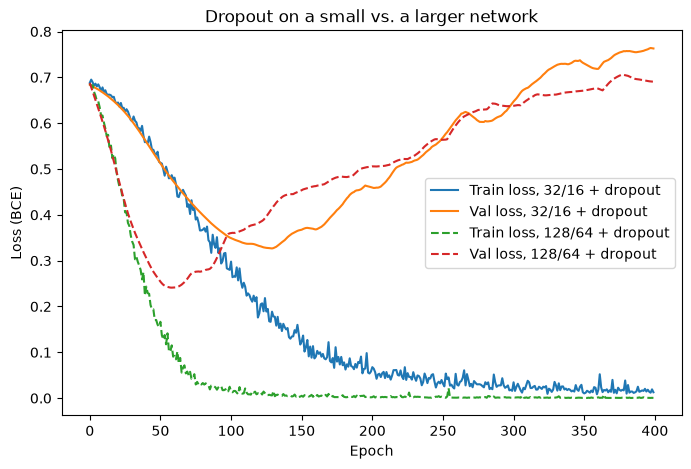

In [6]:
_, train_big, val_big = train_with_val(h1=128, h2=64, dropout_rate=0.3)

gap_small = val_03[-1] - train_03[-1]
gap_big = val_big[-1] - train_big[-1]

print(f"Small (32/16) + dropout=0.3:  final train={train_03[-1]:.4f}  final val={val_03[-1]:.4f}  gap={gap_small:.4f}")
print(f"Large (128/64) + dropout=0.3: final train={train_big[-1]:.4f}  final val={val_big[-1]:.4f}  gap={gap_big:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(train_03, label="Train loss, 32/16 + dropout")
plt.plot(val_03, label="Val loss, 32/16 + dropout")
plt.plot(train_big, label="Train loss, 128/64 + dropout", linestyle="--")
plt.plot(val_big, label="Val loss, 128/64 + dropout", linestyle="--")
plt.xlabel("Epoch")
plt.ylabel("Loss (BCE)")
plt.title("Dropout on a small vs. a larger network")
plt.legend()
plt.show()


**My result**: the small network (32/16 + dropout=0.3) ended at train loss
0.0128 / val loss 0.7630 (gap 0.7502); the larger network (128/64 +
dropout=0.3) ended at train loss 0.0005 / val loss 0.6904 (gap 0.6900). The
larger network's train/val gap was actually slightly *smaller* than the
small network's, despite the 128/64 network having far more trainable
parameters and fitting the training data almost perfectly (train loss
0.0005, versus 0.0128 for the small network). So on this run, dropout did
successfully keep the bigger network's generalization gap from blowing up
in proportion to its extra capacity — it did not eliminate overfitting
(both networks' validation loss sits well above their training loss after
400 epochs), but it kept the bigger network roughly as controlled as the
smaller one, rather than noticeably worse. I would not over-generalize this
single run into "dropout scales for free with any network size" — but it is
a genuine, encouraging result on this dataset.

## Homework 5 — Why compute validation loss inside `with torch.no_grad():`?

*"In your own words, explain why we compute validation loss inside a
`with torch.no_grad():` block — what would go wrong (or just be wasted
effort) if we didn't?"*

`torch.no_grad()` tells PyTorch not to build the autograd computation graph
(the record of every operation needed to later compute gradients via
`.backward()`) for anything inside the block. During validation we only ever
call `model(X_val_t)` and read off the loss to *monitor* it — we never call
`.backward()` or `optimizer.step()` on the validation loss, because updating
the weights from validation data would defeat the entire point of having a
validation set (it would no longer be an honest, untouched check on
generalization). Since no gradients are ever going to be computed from that
forward pass, building the computation graph for it is pure waste: it costs
extra memory (to store every intermediate activation needed for a backward
pass that will never happen) and extra compute, for no benefit. Wrapping the
validation forward pass in `torch.no_grad()` is a correctness-neutral but
efficiency-positive choice — the *validation loss number itself* would come
out identical without it, but the run would be slower and use more memory
for nothing.